### Neuron

![Neuron](neuron.png)

# Perceptron

# MLP (Multi Layer Perceptron)

### 1. Neural Network Overview

![NN-2-2-1](NN.png)


We consider a **feedforward neural network** with the following architecture: 2 inputs, 2 hidden neurons, and 1 output neuron (2–2–1 network) for regression.

#### Forward Pass

For each input $(x_1, x_2)$, the network computes:

$$
z_1 = w_{1,1} x_1 + w_{1,2} x_2 + b_1, \quad a_1 = \text{sigmoid}(z_1)
$$

$$
z_2 = w_{2,1} x_1 + w_{2,2} x_2 + b_2, \quad a_2 = \text{sigmoid}(z_2)
$$

$$
z_3 = w_{3,1} a_1 + w_{3,2} a_2 + b_3, \quad a_3 = z_3
$$

where $\text{sigmoid}(\cdot)$ is the **sigmoid activation function**:

$$
\text{sigmoid}(x) = \sigma(x) = \frac{1}{1 + e^{-x}}
$$

The output neuron is linear, i.e., $a_3 = z_3$, because the network performs **regression**.


### 2. Dataset and Target Function

We generate $m = 500$ random samples $(x_1, x_2)$ uniformly from the interval $[-1, 1]$.

#### Target Function

The network is trained to approximate the following linear target:

$$
y = x_1 + x_2
$$

where $y$ is the true output corresponding to each input pair $(x_1, x_2)$.


### 3. Loss Function

We use the **Mean Squared Error (MSE)** for regression:

$$
L = \frac{1}{2} (a_3 - y)^2
$$

- The factor $\frac{1}{2}$ simplifies the gradient calculation.  
- Minimizing $L$ ensures that the predictions $a_3$ approach the true values $y$.


### 4. Sigmoid Derivative

The sigmoid function is defined as:

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

Its derivative is:

$$
\sigma'(x) = \sigma(x) \big(1 - \sigma(x)\big)
$$

#### Derivation:

$$
\frac{d}{dx} \sigma(x) = \frac{d}{dx} \left(\frac{1}{1 + e^{-x}}\right) 
= \frac{e^{-x}}{(1 + e^{-x})^2} = \sigma(x) \big(1 - \sigma(x)\big)
$$


### 5. Backpropagation

#### Step 1: Output Layer

The derivative of the loss with respect to the output:

$$
\delta_3 = \frac{\partial L}{\partial a_3} = a_3 - y
$$

Gradients for the output layer weights and bias:

$$
\frac{\partial L}{\partial w_{3,1}} = \delta_3 a_1, \quad
\frac{\partial L}{\partial w_{3,2}} = \delta_3 a_2, \quad
\frac{\partial L}{\partial b_3} = \delta_3
$$

#### Step 2: Hidden Layer

For the hidden neurons:

$$
\delta_1 = \delta_3 w_{3,1} \sigma'(z_1), \quad
\delta_2 = \delta_3 w_{3,2} \sigma'(z_2)
$$

Gradients for hidden layer weights and biases:

$$
\frac{\partial L}{\partial w_{1,1}} = \delta_1 x_1, \quad
\frac{\partial L}{\partial w_{1,2}} = \delta_1 x_2, \quad
\frac{\partial L}{\partial b_1} = \delta_1
$$

$$
\frac{\partial L}{\partial w_{2,1}} = \delta_2 x_1, \quad
\frac{\partial L}{\partial w_{2,2}} = \delta_2 x_2, \quad
\frac{\partial L}{\partial b_2} = \delta_2
$$


### 6. Gradient Descent Updates

The parameters are updated using gradient descent:

$$
w \leftarrow w - \eta \frac{\partial L}{\partial w}, \quad
b \leftarrow b - \eta \frac{\partial L}{\partial b}
$$

#### Output Layer Updates:

$$
w_{3,1} \leftarrow w_{3,1} - \eta \delta_3 a_1
$$
$$
w_{3,2} \leftarrow w_{3,2} - \eta \delta_3 a_2
$$
$$
b_3 \leftarrow b_3 - \eta \delta_3
$$

#### Hidden Layer Updates:

$$
w_{1,1} \leftarrow w_{1,1} - \eta \delta_1 x_1, \quad
w_{1,2} \leftarrow w_{1,2} - \eta \delta_1 x_2, \quad
b_1 \leftarrow b_1 - \eta \delta_1
$$

$$
w_{2,1} \leftarrow w_{2,1} - \eta \delta_2 x_1, \quad
w_{2,2} \leftarrow w_{2,2} - \eta \delta_2 x_2, \quad
b_2 \leftarrow b_2 - \eta \delta_2
$$


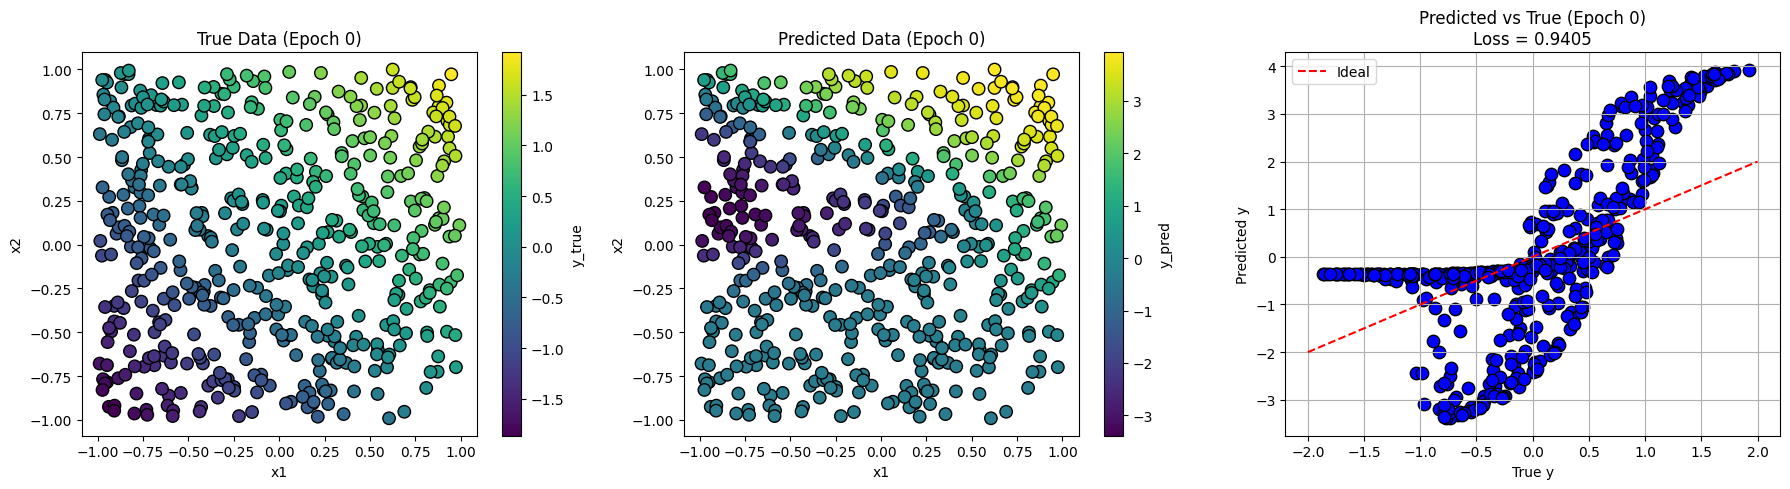

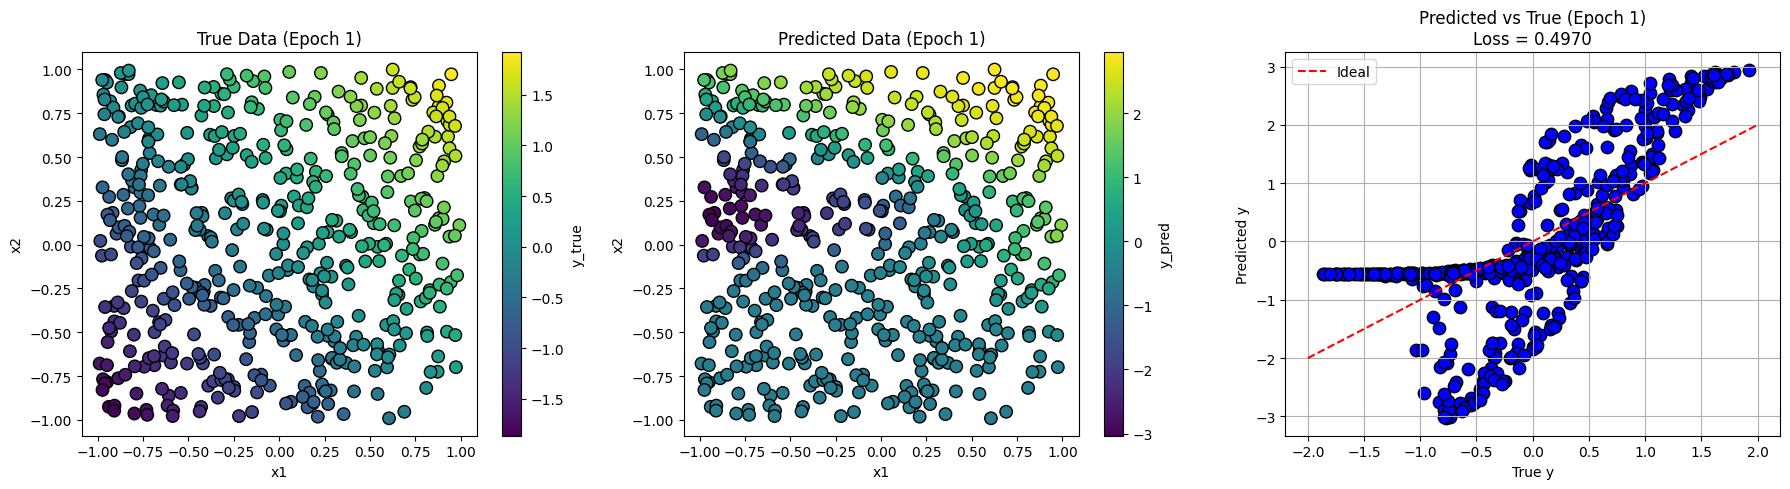

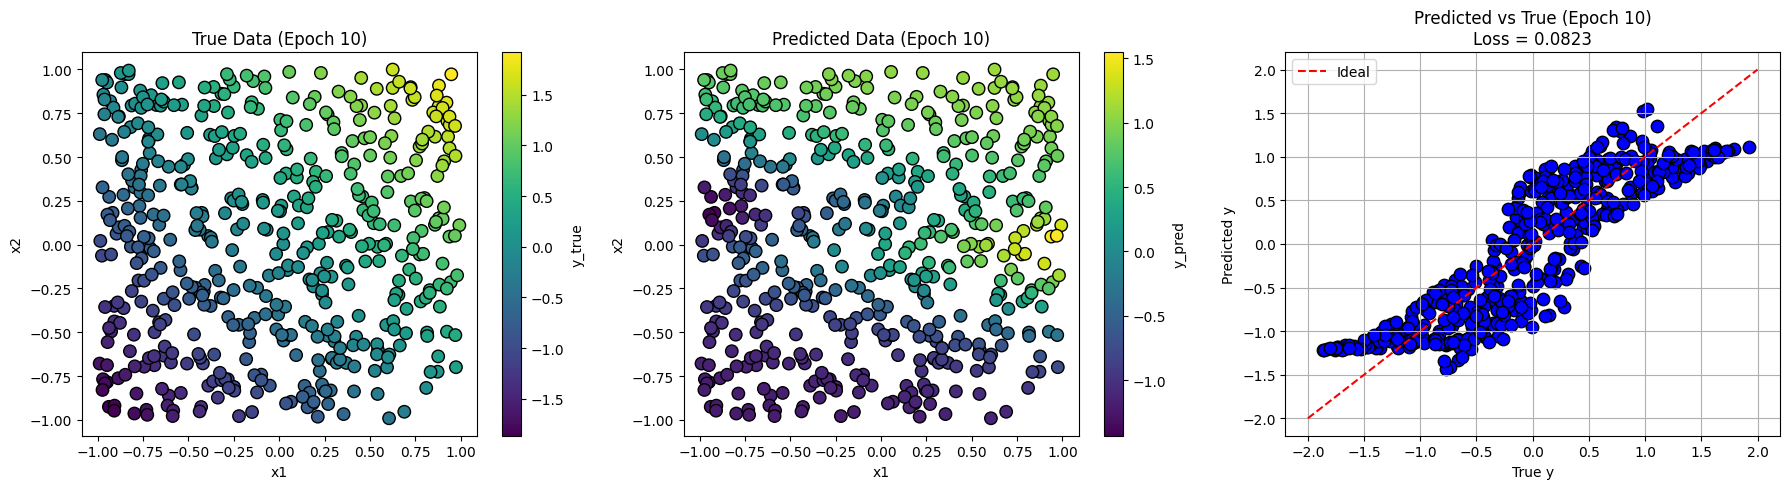

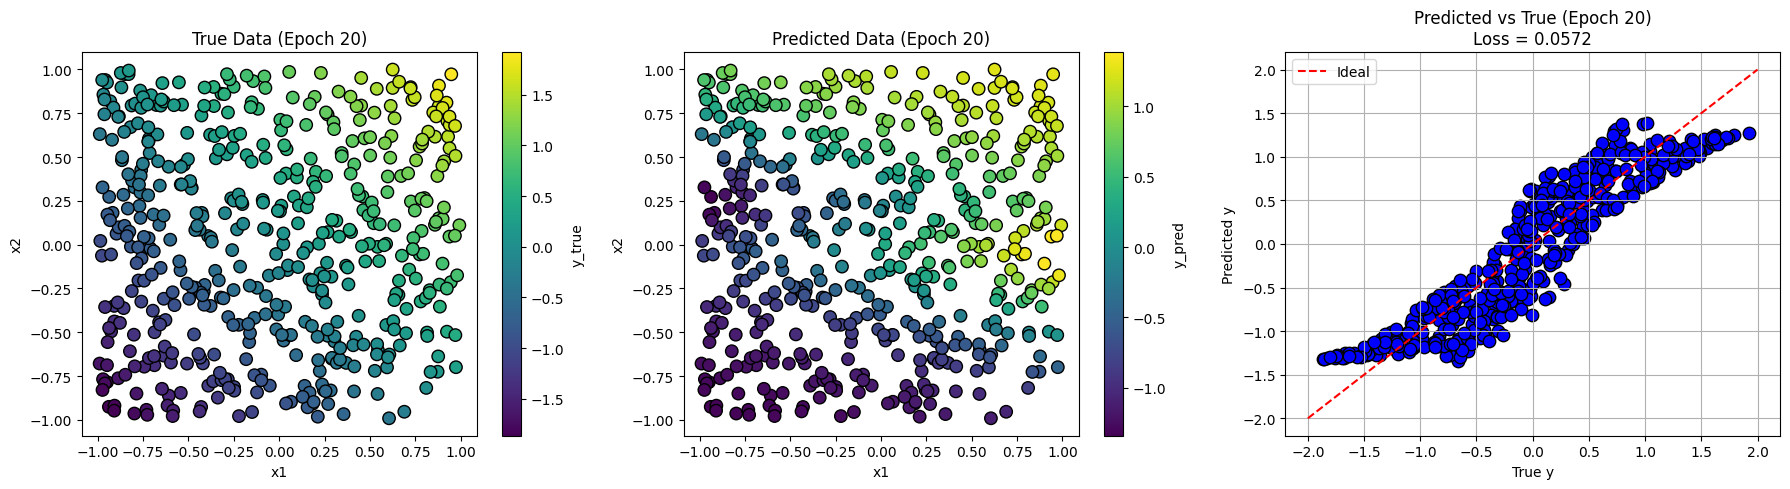

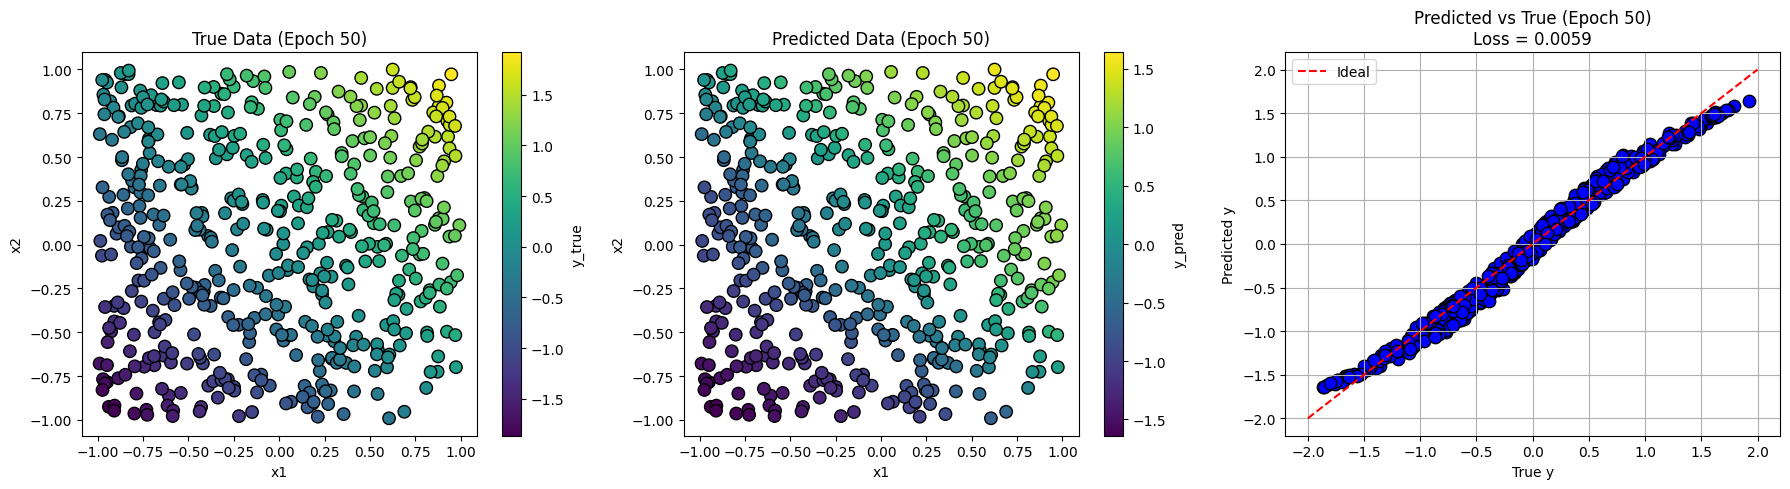

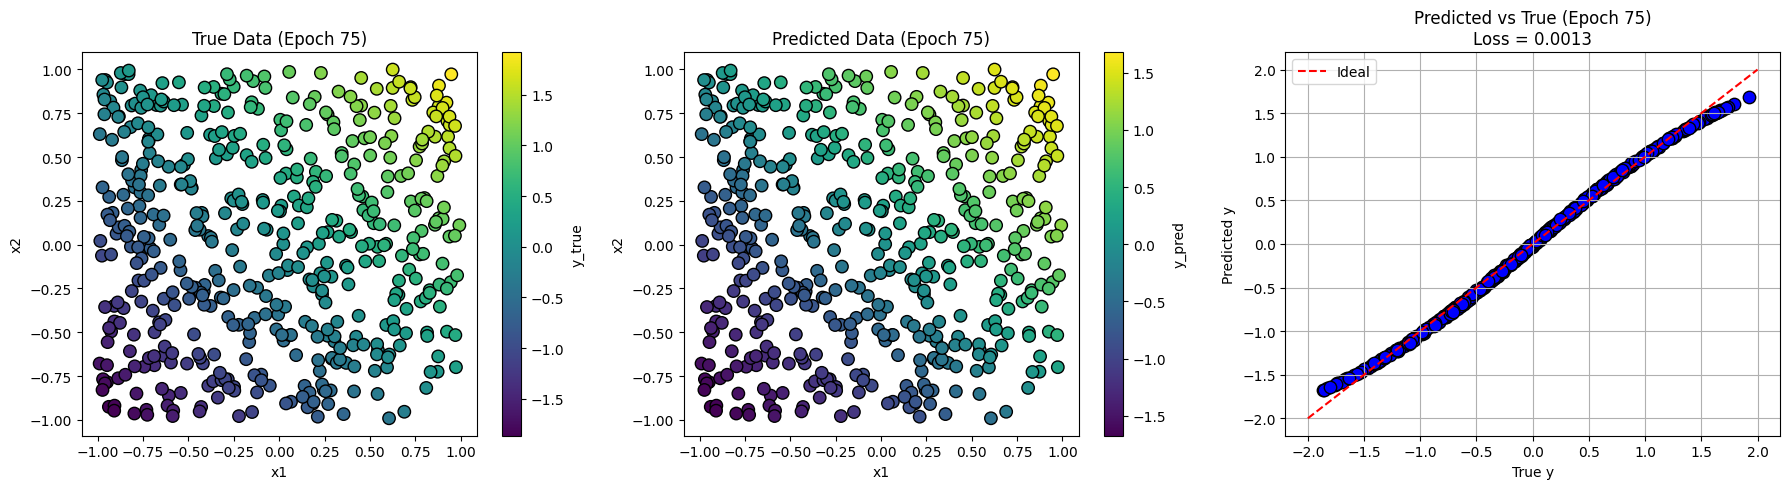

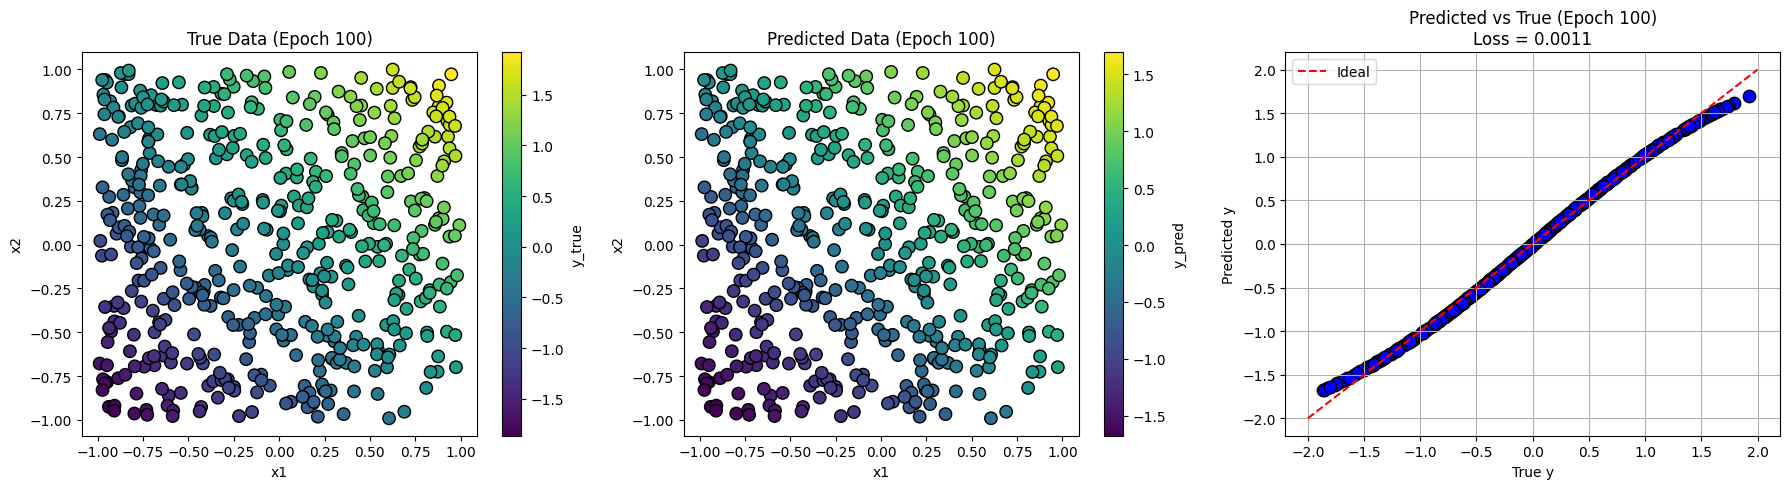

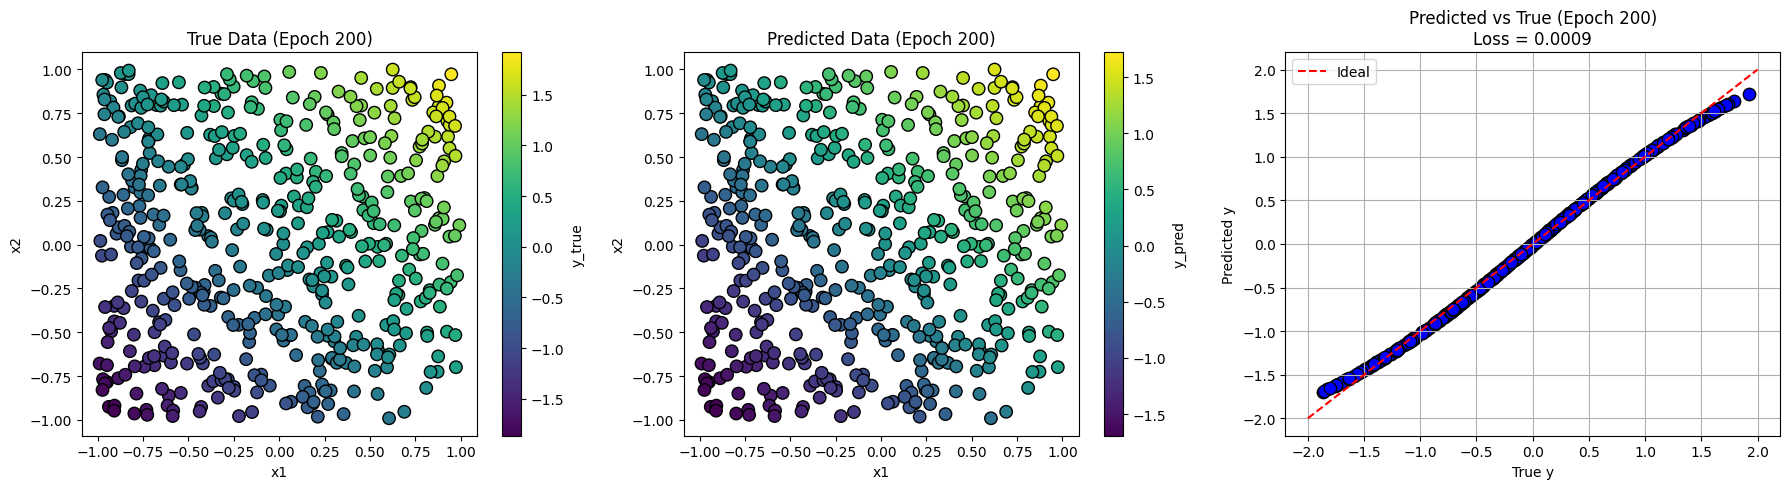

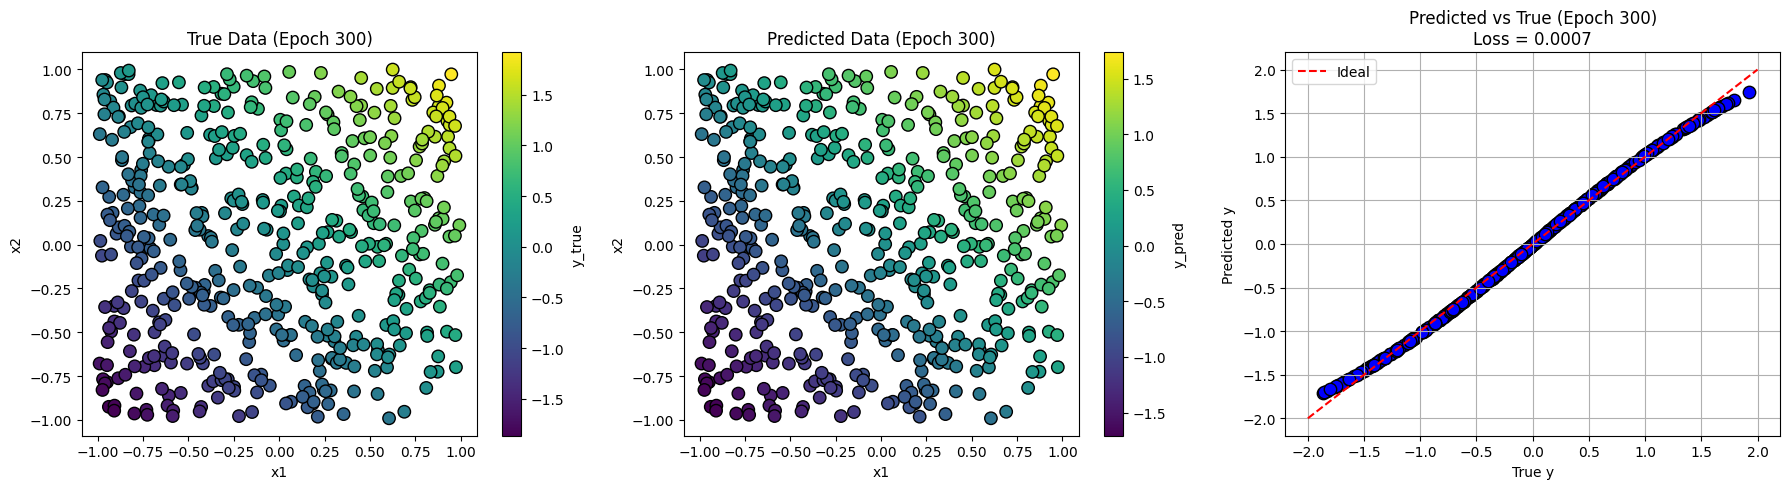

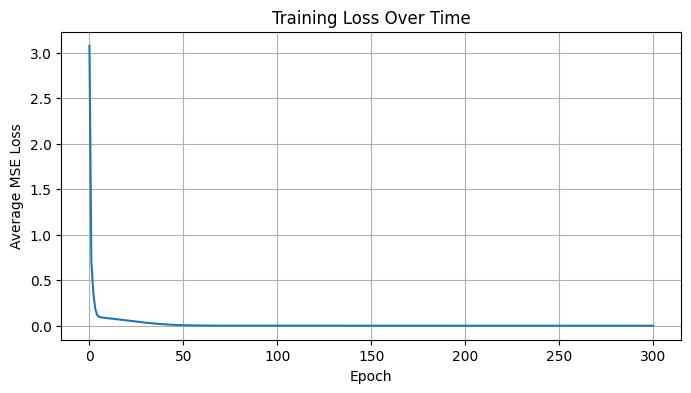

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Sigmoid activation
# -------------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# -------------------------------
# Generate simple linear regression data
# -------------------------------
np.random.seed(42)
num_samples = 500

# Random points in [-1,1] x [-1,1]
X = np.random.uniform(-1, 1, (num_samples, 2))
x1_vals = X[:,0]
x2_vals = X[:,1]

# Target function: simple linear
y_true = (x1_vals + x2_vals).reshape(-1,1)

# -------------------------------
# Initialize weights and biases (2-2-1 network)
# -------------------------------
w_1_1, w_1_2, b_1 = np.random.randn()*10, np.random.randn()*10, 0.0
w_2_1, w_2_2, b_2 = np.random.randn()*10, np.random.randn()*10, 0.0
w_3_1, w_3_2, b_3 = np.random.randn()*10, np.random.randn()*10, 0.0

learning_rate = 0.01
epochs = 300
loss_history = []

# Checkpoints to plot predictions
checkpoints = [0, 1, 10, 20, 50, 75, 100 , 200, 300]

# -------------------------------
# Training loop (MSE regression)
# -------------------------------
for epoch in range(epochs+1):
    total_loss = 0
    for i in range(num_samples):
        x1 = X[i,0]
        x2 = X[i,1]
        y = y_true[i,0]
        
        # --- Forward pass ---
        z1 = w_1_1*x1 + w_1_2*x2 + b_1
        a1 = sigmoid(z1)
        
        z2 = w_2_1*x1 + w_2_2*x2 + b_2
        a2 = sigmoid(z2)
        
        z3 = w_3_1*a1 + w_3_2*a2 + b_3
        a3 = z3  # linear output for regression
        
        # MSE loss
        loss = 0.5 * (a3 - y)**2
        total_loss += loss
        
        # --- Backpropagation ---
        dL_da3 = a3 - y
        dL_dz3 = dL_da3  # linear output derivative
        
        # Output neuron gradients
        dL_dw_3_1 = dL_dz3 * a1
        dL_dw_3_2 = dL_dz3 * a2
        dL_db_3   = dL_dz3
        
        # Hidden layer gradients
        dL_da1 = dL_dz3 * w_3_1
        dL_da2 = dL_dz3 * w_3_2
        
        dL_dz1 = dL_da1 * sigmoid_derivative(z1)
        dL_dz2 = dL_da2 * sigmoid_derivative(z2)
        
        dL_dw_1_1 = dL_dz1 * x1
        dL_dw_1_2 = dL_dz1 * x2
        dL_db_1   = dL_dz1
        
        dL_dw_2_1 = dL_dz2 * x1
        dL_dw_2_2 = dL_dz2 * x2
        dL_db_2   = dL_dz2
        
        # Gradient descent update
        w_1_1 -= learning_rate * dL_dw_1_1
        w_1_2 -= learning_rate * dL_dw_1_2
        b_1   -= learning_rate * dL_db_1
        
        w_2_1 -= learning_rate * dL_dw_2_1
        w_2_2 -= learning_rate * dL_dw_2_2
        b_2   -= learning_rate * dL_db_2
        
        w_3_1 -= learning_rate * dL_dw_3_1
        w_3_2 -= learning_rate * dL_dw_3_2
        b_3   -= learning_rate * dL_db_3
    
    loss_history.append(total_loss / num_samples)
    
    # -------------------------------
    # Plot predictions at checkpoints
    # -------------------------------
    if epoch in checkpoints:
        y_pred = []
        for j in range(num_samples):
            x1 = X[j,0]
            x2 = X[j,1]
            a1 = sigmoid(w_1_1*x1 + w_1_2*x2 + b_1)
            a2 = sigmoid(w_2_1*x1 + w_2_2*x2 + b_2)
            a3 = w_3_1*a1 + w_3_2*a2 + b_3
            y_pred.append(a3)
        y_pred = np.array(y_pred).flatten()
        
        # --- Horizontal subplots ---
        fig, axs = plt.subplots(1, 3, figsize=(18,5))
        
        # 1. True data
        sc0 = axs[0].scatter(x1_vals, x2_vals, c=y_true.flatten(), cmap='viridis', edgecolor='k', s=80)
        axs[0].set_xlabel("x1")
        axs[0].set_ylabel("x2")
        axs[0].set_title(f"True Data (Epoch {epoch})")
        plt.colorbar(sc0, ax=axs[0], label="y_true")
        
        # 2. Predicted data
        sc1 = axs[1].scatter(x1_vals, x2_vals, c=y_pred, cmap='viridis', edgecolor='k', s=80)
        axs[1].set_xlabel("x1")
        axs[1].set_ylabel("x2")
        axs[1].set_title(f"Predicted Data (Epoch {epoch})")
        plt.colorbar(sc1, ax=axs[1], label="y_pred")
        
        # 3. Predicted vs True y
        axs[2].scatter(y_true, y_pred, c='blue', edgecolor='k', s=80)
        axs[2].plot([-2,2], [-2,2], 'r--', label='Ideal')
        axs[2].set_xlabel("True y")
        axs[2].set_ylabel("Predicted y")

        # Compute loss for this checkpoint
        checkpoint_loss = np.mean(0.5 * (y_pred - y_true.flatten())**2)

        axs[2].set_title(f"Predicted vs True (Epoch {epoch})\nLoss = {checkpoint_loss:.4f}")
        axs[2].legend()
        axs[2].grid(True)

        
        plt.tight_layout()
        plt.show()

# -------------------------------
# Final loss plot
# -------------------------------
plt.figure(figsize=(8,4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Average MSE Loss")
plt.title("Training Loss Over Time")
plt.grid(True)
plt.show()


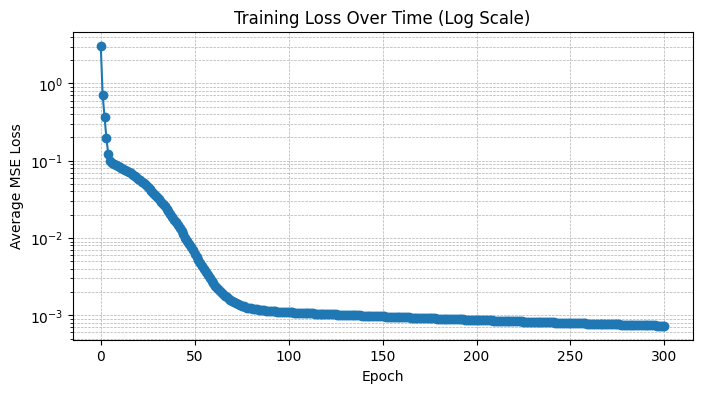

In [12]:
# -------------------------------
# Final loss plot (logarithmic y-axis)
# -------------------------------
plt.figure(figsize=(8,4))
plt.plot(loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average MSE Loss")
plt.title("Training Loss Over Time (Log Scale)")
plt.yscale('log')  # logarithmic scale
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()
